In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from numba import jit

mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['font.size'] = 16               # 본문 크기
mpl.rcParams['axes.labelsize'] = 18         # 축 라벨
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16
mpl.rcParams['legend.fontsize'] = 16
mpl.rcParams['mathtext.fontset'] = 'cm'      # LaTeX 수식은 Computer Modern 유지
mpl.rcParams['axes.linewidth'] = 1.0   # 

In [2]:
from Simul import get_RQ_MOA4,get_RQ_MOA5,get_RQ_MOA2,get_R_simul_wfT,RK4,to_complex
import numpy as np
import matplotlib.pyplot as plt
from parfor import parfor

In [3]:
alphas = np.linspace(0,np.pi/2,100)
betas = np.linspace(0,1,101)[1:]

In [4]:
SIM = np.load('SIMUL N10000/ALPHA pi4 mu 0.5.npz')

In [5]:
A =  np.load(f'SIMUL N10000/alpha = {alphas[0]}.npz')
N = 10000
Q1s = np.zeros((100,100,len(A['Q1'][0])))
Q2s = np.zeros((100,100,len(A['Q2'][0])))
R1s = np.zeros((100,100,len(A['R1'][0])))
R2s = np.zeros((100,100,len(A['R2'][0])))
for i,beta in enumerate(betas):
    A =  np.load(f'SIMUL OA/beta = {beta} N = {N}.npz')
    Q1s[i,:,:] = A['Q1']
    Q2s[i,:,:] = A['Q2']
    R2s[i,:,:] = A['R2']
    R1s[i,:,:] = A['R1']
Q1s_sim = np.zeros((100,100,len(A['Q1'][0])))
Q2s_sim = np.zeros((100,100,len(A['Q2'][0])))
R1s_sim = np.zeros((100,100,len(A['R1'][0])))
R2s_sim = np.zeros((100,100,len(A['R2'][0])))
for i,alpha in enumerate(alphas):
    A =  np.load(f'SIMUL N10000/alpha = {alpha}.npz')
    # A =  np.load(f'SIMUL N1000 uniform/alpha = {alpha}.npz')
    Q1s_sim[:,i,:] = A['Q1']
    Q2s_sim[:,i,:] = A['Q2']
    R2s_sim[:,i,:] = A['R2']
    R1s_sim[:,i,:] = A['R1']

In [6]:
t= SIM['t']
# Q1_sim = SIM['Q1']
Q2 = SIM['Q2']
Z2bs = SIM['Q2_sim']

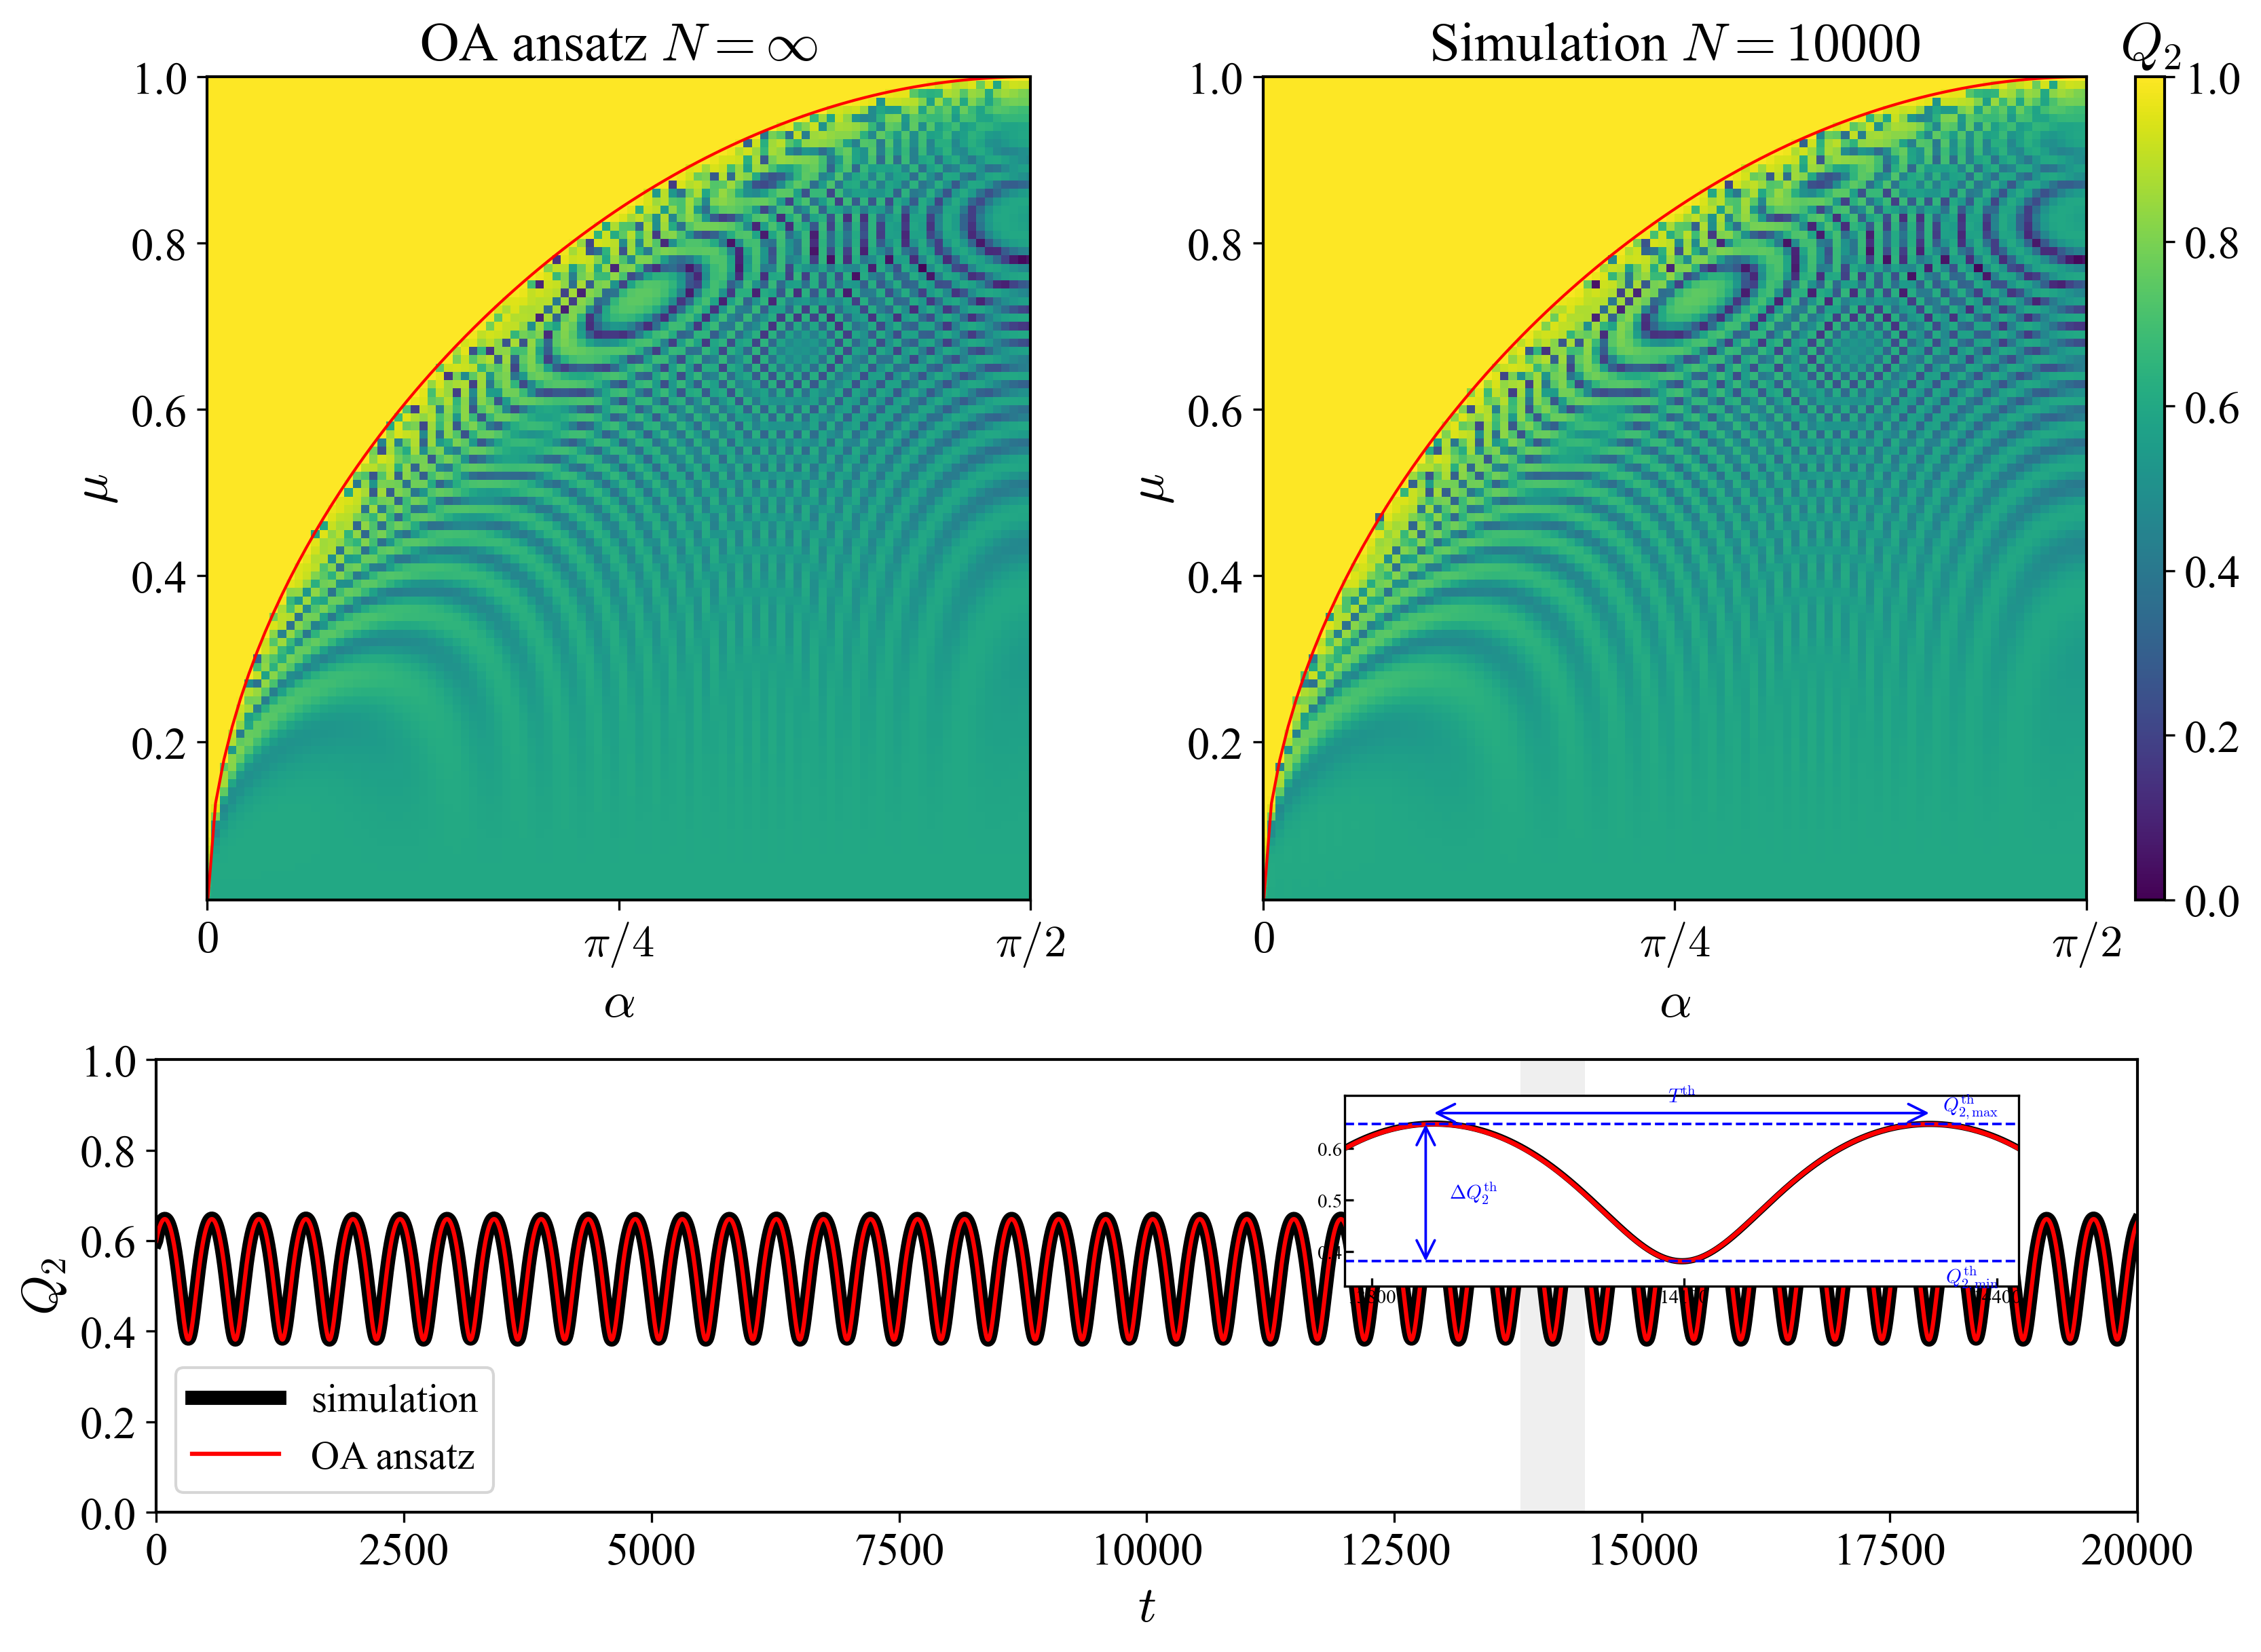

In [ ]:
fig = plt.figure(figsize=(11, 8), dpi=300, constrained_layout=True)

gs = fig.add_gridspec(
    2, 2,
    height_ratios=[1, 0.55],
    width_ratios=[1, 1]
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

index = -1

# -------------------------
# Top-left
# -------------------------
im1 = ax1.pcolormesh(
    alphas, betas, Q2s[:, :, index],
    vmin=0, vmax=1,
    shading='auto'
)
ax1.set_title(r'OA ansatz $N=\infty$')
ax1.set_box_aspect(1)

# -------------------------
# Top-right
# -------------------------
im2 = ax2.pcolormesh(
    alphas, betas, Q2s_sim[:, :, index],
    vmin=0, vmax=1,
    shading='auto'
)
ax2.set_title(r'Simulation $N=10000$')
ax2.set_box_aspect(1)

# -------------------------
# Shared colorbar
# ax2 기준으로 높이 100%짜리 colorbar 생성
# -------------------------
cax = ax2.inset_axes([1.06, 0.0, 0.035, 1.0])
cbar = fig.colorbar(im2, cax=cax)
cbar.ax.set_title(r'$Q_2$')

# -------------------------
# Axis formatting
# -------------------------
for ax in [ax1, ax2]:
    ax.plot(alphas, np.sqrt(np.sin(alphas)), color='red', lw=1)

    ax.set_xlabel(r'$\alpha$')
    ax.set_ylabel(r'$\mu$')

    ax.set_xlim(0, np.pi / 2)
    ax.set_ylim(betas[0], 1)

    ax.set_xticks([0, np.pi/4, np.pi/2])
    ax.set_xticklabels([r'$0$', r'$\pi/4$', r'$\pi/2$'])

# -------------------------
# Bottom time series
# -------------------------
# -------------------------
# Bottom time series
# -------------------------
ax3.plot(t, np.abs(Z2bs), label='simulation', lw=5, color='black')
ax3.plot(t, np.abs(Q2), label='OA ansatz', color='red')

ax3.set_xlim(0, 20000)
ax3.set_ylim(0, 1)
ax3.set_xlabel(r'$t$')
ax3.set_ylabel(r'$Q_2$')
ax3.legend()
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

# -------------------------
# Theoretical quantities
# -------------------------
mu = 0.5
alpha = np.pi/4
eta = 0.45
phi0 = 0.0
Q20 = 0.6

A = mu**2 * (2*eta - 1)**2
B = np.sin(alpha) * (2*eta - 1)**2

Phi0 = 2*phi0 + alpha
X0 = Q20 * np.cos(Phi0)
Y0 = Q20 * np.sin(Phi0)

C0 = (B - A*Y0) / (1 - X0**2 - Y0**2)

yc = A / (2*C0)
Rc = np.sqrt(A**2 - 4*C0*(B - C0)) / (2*np.abs(C0))

Q2_max_th = np.abs(yc) + Rc
Q2_min_th = np.abs(np.abs(yc) - Rc)
dQ2_th = Q2_max_th - Q2_min_th

T_th = np.pi / ((1 - 2*eta)**2 * np.sqrt(np.sin(alpha)**2 - mu**4))

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np

# -------------------------
# Theoretical quantities
# -------------------------
mu = 0.5
alpha = np.pi/4
eta = 0.45
phi0 = 0.0
Q20 = 0.6

A = mu**2 * (2*eta - 1)**2
B = np.sin(alpha) * (2*eta - 1)**2

Phi0 = 2*phi0 + alpha
X0 = Q20 * np.cos(Phi0)
Y0 = Q20 * np.sin(Phi0)

C0 = (B - A*Y0) / (1 - X0**2 - Y0**2)

yc = A / (2*C0)
Rc = np.sqrt(A**2 - 4*C0*(B - C0)) / (2*np.abs(C0))

Q2_max_th = np.abs(yc) + Rc
Q2_min_th = np.abs(np.abs(yc) - Rc)
dQ2_th = Q2_max_th - Q2_min_th

T_th = np.pi / ((1 - 2*eta)**2 * np.sqrt(np.sin(alpha)**2 - mu**4))

# -------------------------
# Data
# -------------------------
Q2_sim_abs = np.abs(Z2bs)
Q2_oa_abs  = np.abs(Q2)

# -------------------------
# Choose one clean period automatically
# -------------------------
t_search_min = 12000
t_search_max = 15000

mask_search = (t >= t_search_min) & (t <= t_search_max)
tt = t[mask_search]
yy = Q2_oa_abs[mask_search]

# local maxima
local_max_idx = np.where((yy[1:-1] > yy[:-2]) & (yy[1:-1] > yy[2:]))[0] + 1

# 가운데쯤 있는 peak 선택
i_peak = local_max_idx[len(local_max_idx)//2]
t_peak = tt[i_peak]

# 한 주기 + 약간의 margin
t_zoom_min = t_peak - 0.18*T_th
t_zoom_max = t_peak + 1.18*T_th

mask_zoom = (t >= t_zoom_min) & (t <= t_zoom_max)

# -------------------------
# Inset axis
# -------------------------
axins = ax3.inset_axes([0.60, 0.50, 0.34, 0.42])
axins.set_facecolor('white')

axins.plot(t, Q2_sim_abs, lw=2.2, color='black')
axins.plot(t, Q2_oa_abs,  lw=1.6, color='red')

axins.set_xlim(t_zoom_min, t_zoom_max)

pad = 0.18*dQ2_th
axins.set_ylim(Q2_min_th - pad, Q2_max_th + 1.15*pad)

# tick을 최소화
axins.tick_params(
    axis='both',
    labelsize=7,
    direction='in',
    length=3,
    pad=1
)

axins.set_xticks([
    np.round(t_zoom_min/100)*100,
    np.round((t_zoom_min+t_zoom_max)/2/100)*100,
    np.round(t_zoom_max/100)*100
])
axins.set_yticks([0.4, 0.5, 0.6])

# label 제거: inset에서는 축 라벨이 없어야 깔끔함
axins.set_xlabel('')
axins.set_ylabel('')

# inset border 얇게
for spine in axins.spines.values():
    spine.set_linewidth(0.8)

# -------------------------
# Theoretical max/min lines
# -------------------------
axins.axhline(Q2_max_th, color='blue', ls='--', lw=0.9)
axins.axhline(Q2_min_th, color='blue', ls='--', lw=0.9)

# max/min label은 오른쪽에 짧게
x_label = t_zoom_max - 0.03*(t_zoom_max - t_zoom_min)

axins.text(
    x_label, Q2_max_th + 0.025*dQ2_th,
    r'$Q_{2,\max}^{\rm th}$',
    fontsize=7,
    color='blue',
    ha='right',
    va='bottom'
)

axins.text(
    x_label, Q2_min_th - 0.025*dQ2_th,
    r'$Q_{2,\min}^{\rm th}$',
    fontsize=7,
    color='blue',
    ha='right',
    va='top'
)

# -------------------------
# Theoretical amplitude ΔQ2
# -------------------------
x_amp = t_zoom_min + 0.12*(t_zoom_max - t_zoom_min)

axins.annotate(
    '',
    xy=(x_amp, Q2_min_th),
    xytext=(x_amp, Q2_max_th),
    arrowprops=dict(
        arrowstyle='<->',
        lw=0.9,
        color='blue',
        shrinkA=0,
        shrinkB=0
    )
)

axins.text(
    x_amp + 0.035*(t_zoom_max - t_zoom_min),
    0.5*(Q2_min_th + Q2_max_th),
    r'$\Delta Q_2^{\rm th}$',
    fontsize=7,
    color='blue',
    va='center',
    ha='left'
)

# -------------------------
# Theoretical period T
# -------------------------
t1 = t_peak
t2 = t_peak + T_th

y_T = Q2_max_th + 0.45*pad

axins.annotate(
    '',
    xy=(t1, y_T),
    xytext=(t2, y_T),
    arrowprops=dict(
        arrowstyle='<->',
        lw=0.9,
        color='blue',
        shrinkA=0,
        shrinkB=0
    )
)

axins.text(
    0.5*(t1 + t2),
    y_T + 0.05*dQ2_th,
    r'$T^{\rm th}$',
    fontsize=7,
    color='blue',
    ha='center',
    va='bottom'
)

# -------------------------
# Optional: mark zoomed region on main axis lightly
# -------------------------
ax3.axvspan(
    t_zoom_min, t_zoom_max,
    color='gray',
    alpha=0.12,
    lw=0
)


In [ ]:
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
import numpy as np

# -------------------------
# parameters for the bottom time-series panel
# (이 부분은 현재 그린 bottom panel의 parameter로 맞춰주세요)
# 예시:
# alpha = 0.7
# mu    = 0.5
# eta   = 0.45
# phi0  = 0.0
# Q20   = 0.6
# -------------------------

# 이론량


Text(15522.282082344747, 0.6982443904218474, '$T^{\\mathrm{th}}$')

Text(14097.382082344746, 0.6774804077648872, '$T^{\\rm th}$')

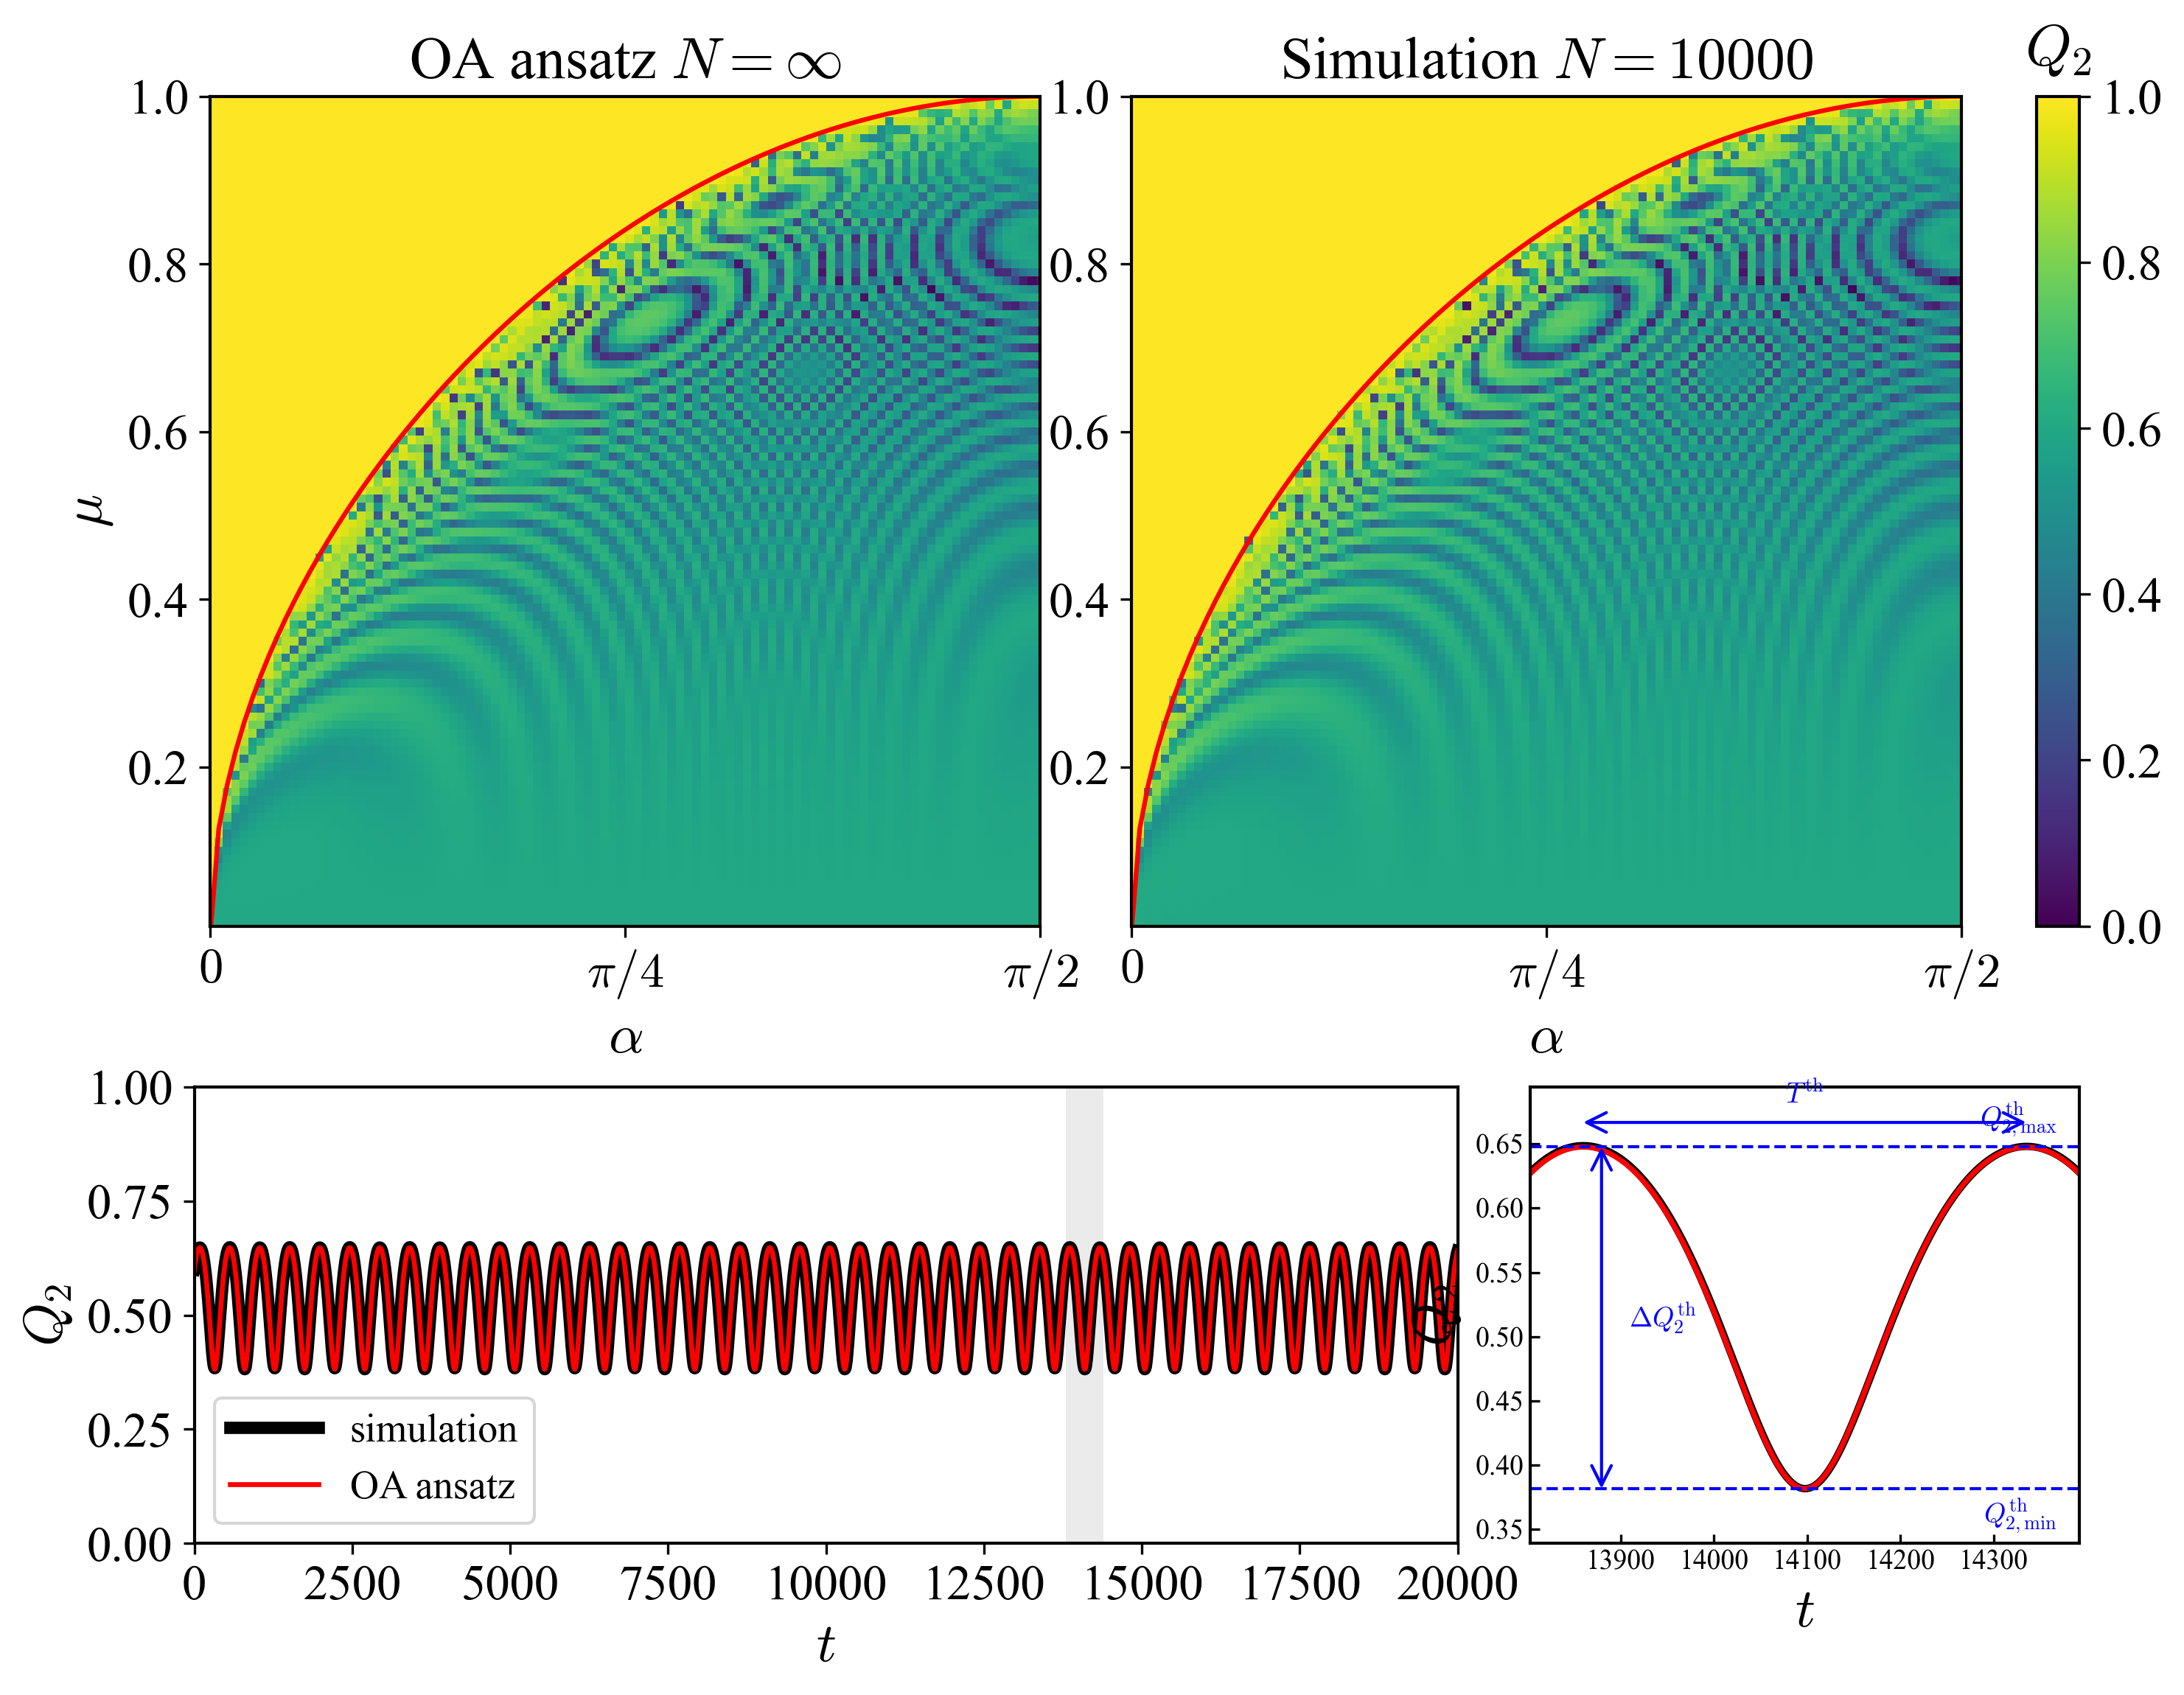

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 자동 레이아웃 충돌 방지를 위해 constrained_layout=False (기본값) 유지
fig = plt.figure(figsize=(11, 8.5), dpi=300)

# 2행 3열 구조
gs = fig.add_gridspec(
    2, 3,
    height_ratios=[1, 0.55],      # 위/아래 패널 높이 비율
    width_ratios=[1, 1, 0.05],    # 왼쪽패널(1) : 오른쪽패널(1) : 컬러바(0.05)
    wspace=0.1,                   # 좌우 패널 사이의 간격 (더 땡기고 싶으면 0.05 등으로 축소)
    hspace=0.25                   # 상하 패널 사이의 간격
)

# --- 축(Axes) 할당 ---
ax1 = fig.add_subplot(gs[0, 0])   # Top-left
ax2 = fig.add_subplot(gs[0, 1])   # Top-right
cax = fig.add_subplot(gs[0, 2])   # Top-far-right (컬러바 전용)

# [핵심] 아래쪽 패널이 왼쪽부터 컬러바 끝까지 전체 너비를 꽉 채우도록 설정 (:)
ax3 = fig.add_subplot(gs[1, :])   

# --- 비율 강제 ---
# 정사각형 비율을 유지하려면 아래 코드를 사용합니다.
# 단, figsize의 비율과 맞지 않으면 빈 여백이 생길 수 있으므로, 
# 여백이 거슬린다면 set_box_aspect(1)을 지우고 GridSpec이 주는 비율 그대로 쓰는 것도 방법입니다.
ax1.set_box_aspect(1)
ax2.set_box_aspect(1)

# -------------------------
# Top-left (OA ansatz)
# -------------------------
# [중요] 논문 제출 시 pcolormesh로 인해 PDF 파일이 수십 MB로 커지는 것을 막기 위해 rasterized=True 필수
im1 = ax1.pcolormesh(
    alphas, betas, Q2s[:, :, index], 
    vmin=0, vmax=1, shading='auto', rasterized=True
)
ax1.set_title(r'OA ansatz $N=\infty$')
ax1.set_box_aspect(1)

# -------------------------
# Top-right (Simulation)
# -------------------------
im2 = ax2.pcolormesh(
    alphas, betas, Q2s_sim[:, :, index], 
    vmin=0, vmax=1, shading='auto', rasterized=True
)
ax2.set_title(r'Simulation $N=10000$')
ax2.set_box_aspect(1)

# -------------------------
# Shared colorbar
# -------------------------
cbar = fig.colorbar(im2, cax=cax)
cbar.ax.set_title(r'$Q_2$', pad=10)

# -------------------------
# Axis formatting (Top panels)
# -------------------------
for ax in [ax1, ax2]:
    ax.plot(alphas, np.sqrt(np.sin(alphas)), color='red', lw=1.5)
    ax.set_xlabel(r'$\alpha$')
    ax.set_xlim(0, np.pi / 2)
    ax.set_ylim(betas[0], 1)
    ax.set_xticks([0, np.pi/4, np.pi/2])
    ax.set_xticklabels([r'$0$', r'$\pi/4$', r'$\pi/2$'])
ax1.set_ylabel(r'$\mu$')

# -------------------------
# Bottom time series (Simulation vs OA)
# -------------------------
# 아래 패널은 작은데 lw=5는 너무 두꺼워 떡져 보일 수 있어 조절했습니다.
ax3.plot(t, np.abs(Z2bs), label='Simulation', lw=4, color='black')
ax3.plot(t, np.abs(Q2), label='OA ansatz', lw=1.5, color='red')

# 말씀하신 전체 시뮬레이션 시간 반영
ax3.set_yticks([0,0.5,1])  # y축 눈금 추가
ax3.set_xticks([0,5000,10000,15000,20000])  # x축 눈금 추가
ax3.set_xlim(0, 20000) 
ax3.set_ylim(0, 1)
ax3.set_xlabel(r'$t$')
ax3.set_ylabel(r'$Q_2$')

# 논문 그림은 독자가 캡션을 안 봐도 어떤 파라미터인지 직관적으로 알 수 있게 박스 처리해 주면 좋습니다.

ax3.legend(loc='lower right', framealpha=0)

plt.show()

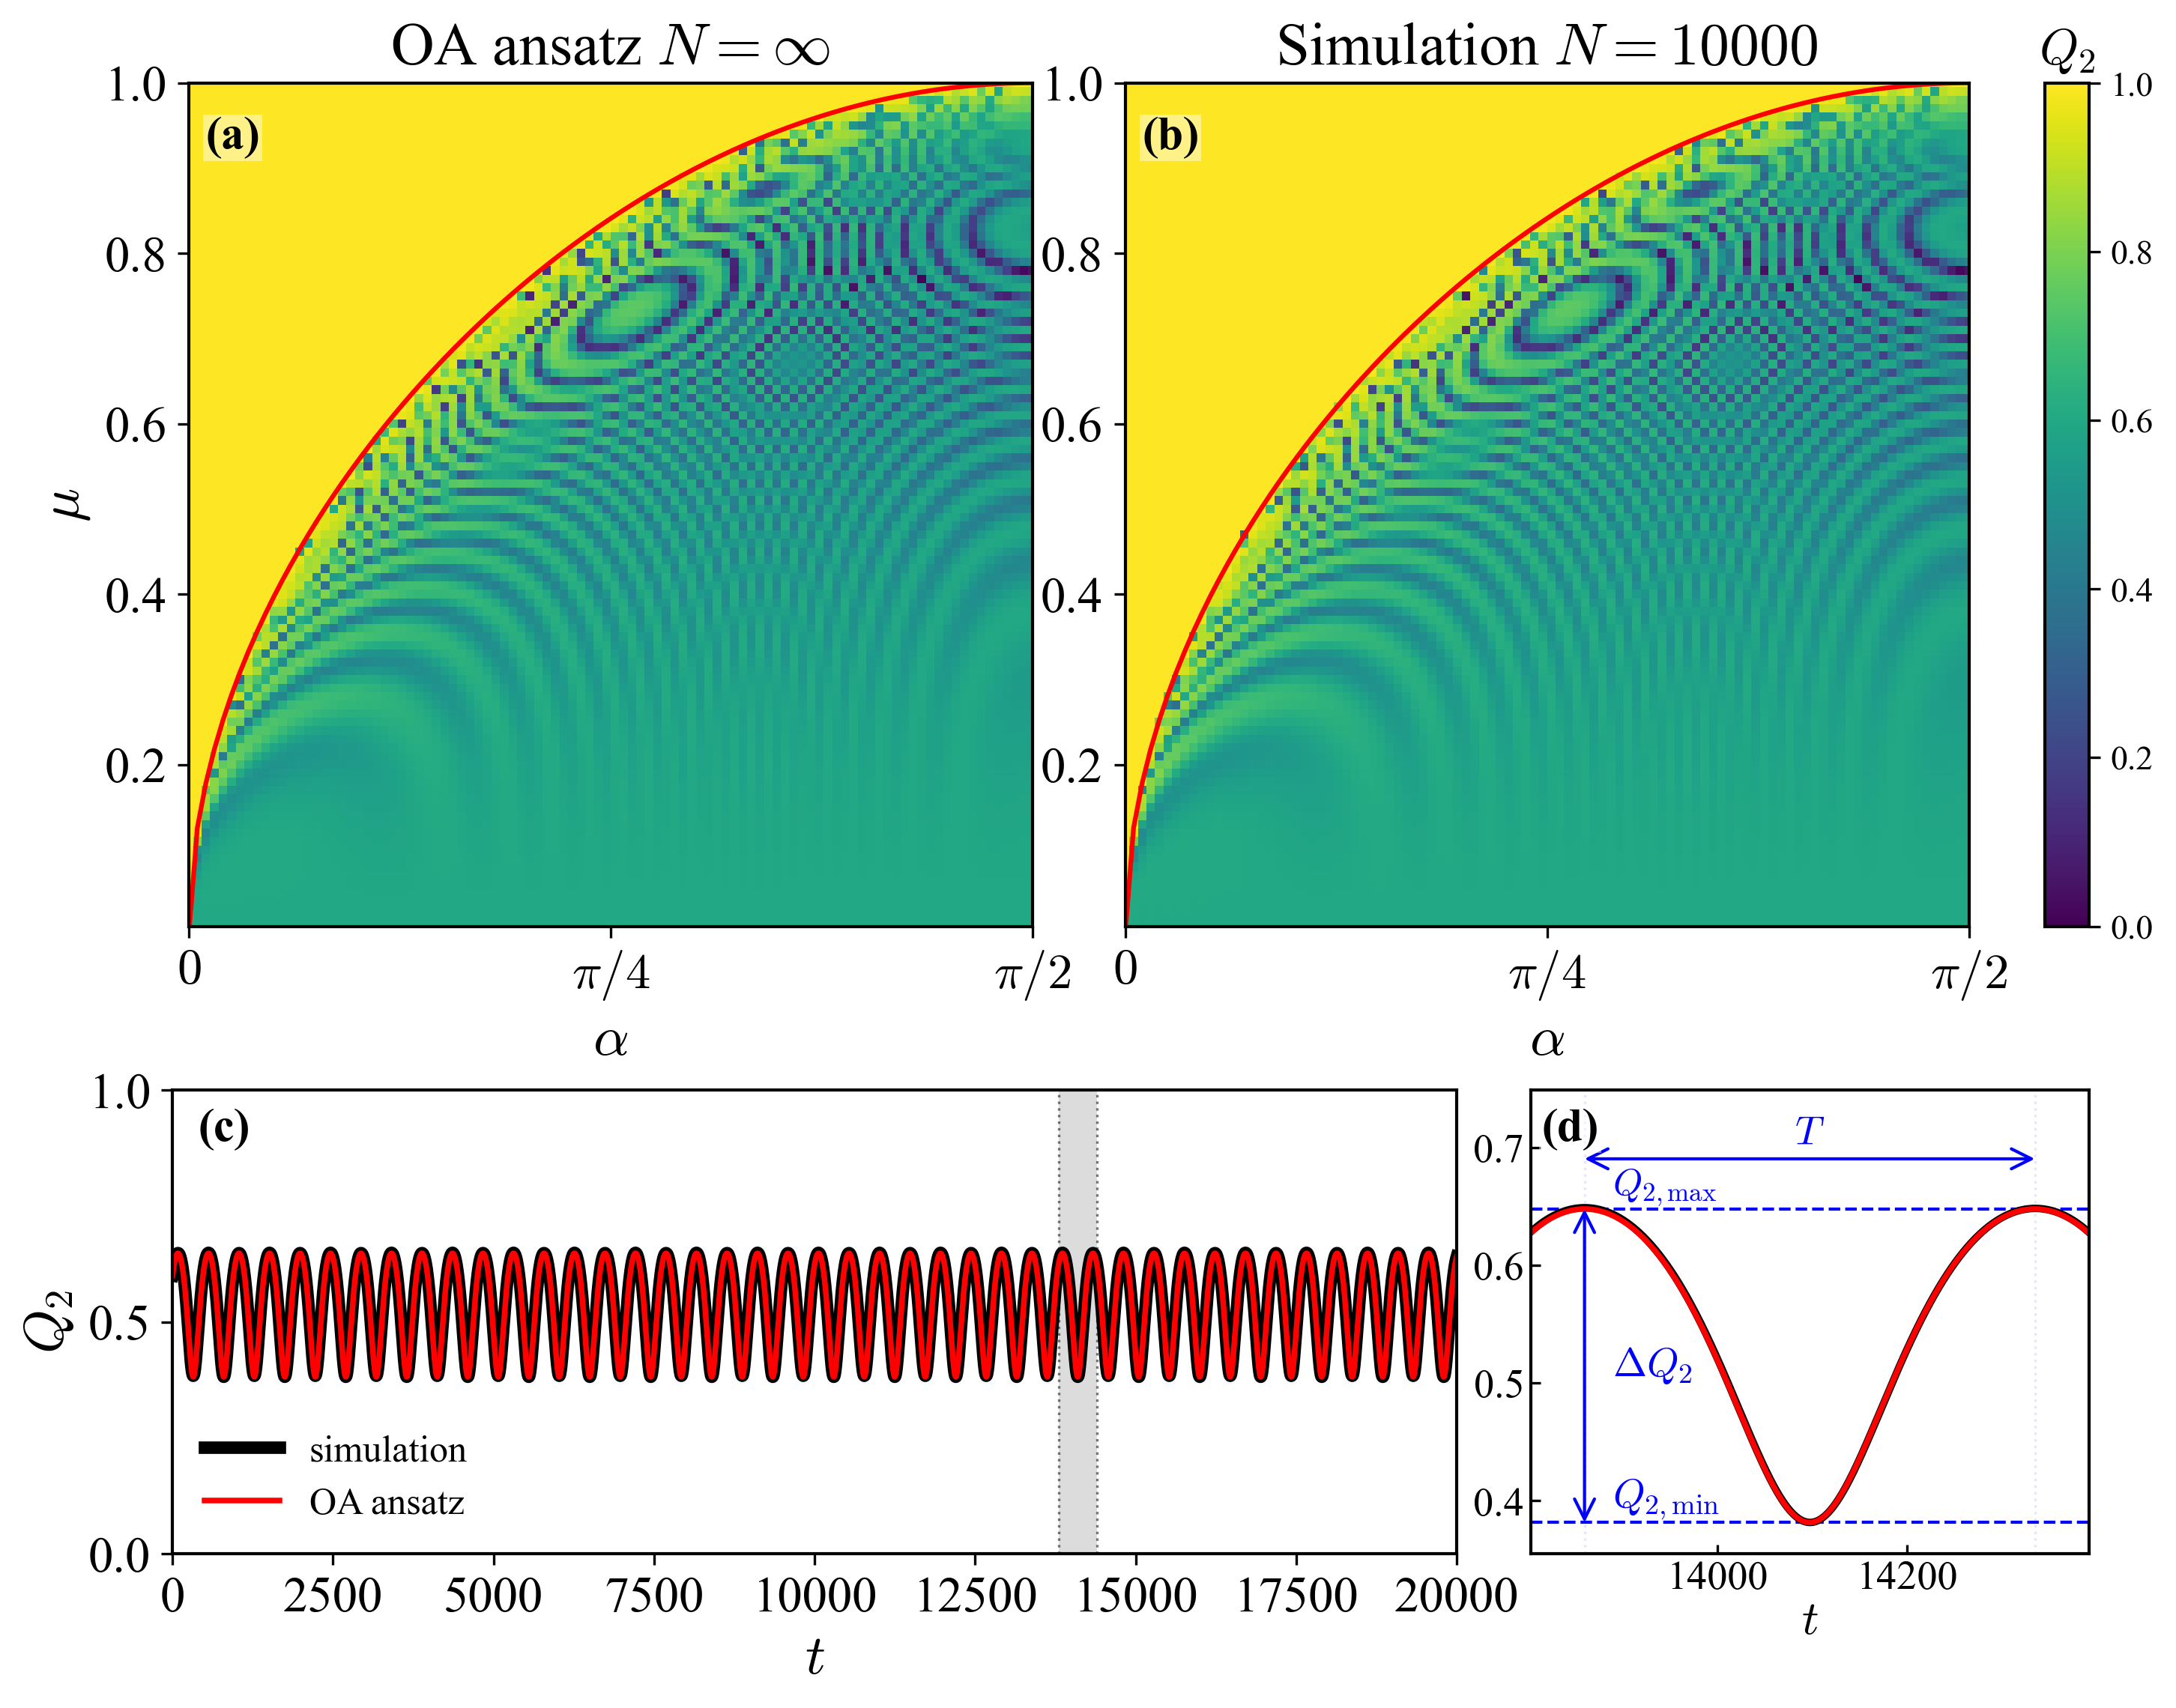

In [70]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 0. User parameters
# ============================================================
index = -1

mu = 0.5
alpha = np.pi / 4
eta = 0.45
phi0 = 0.0
Q20 = 0.6

t_search_min = 12000
t_search_max = 15000


# ============================================================
# 1. Helper functions
# ============================================================
def compute_theory_values(mu, alpha, eta, phi0, Q20):
    """
    Compute theoretical extrema, amplitude, and period of Q2(t).
    """
    A = mu**2 * (2 * eta - 1)**2
    B = np.sin(alpha) * (2 * eta - 1)**2

    Phi0 = 2 * phi0 + alpha
    X0 = Q20 * np.cos(Phi0)
    Y0 = Q20 * np.sin(Phi0)

    C0 = (B - A * Y0) / (1 - X0**2 - Y0**2)

    yc = A / (2 * C0)

    disc = A**2 - 4 * C0 * (B - C0)
    disc = np.maximum(disc, 0.0)

    Rc = np.sqrt(disc) / (2 * np.abs(C0))

    Q2_max_th = np.abs(yc) + Rc
    Q2_min_th = np.abs(np.abs(yc) - Rc)
    dQ2_th = Q2_max_th - Q2_min_th

    T_th = np.pi / ((1 - 2 * eta)**2 * np.sqrt(np.sin(alpha)**2 - mu**4))

    return {
        "A": A,
        "B": B,
        "C0": C0,
        "yc": yc,
        "Rc": Rc,
        "Q2_max_th": Q2_max_th,
        "Q2_min_th": Q2_min_th,
        "dQ2_th": dQ2_th,
        "T_th": T_th,
    }


def select_zoom_window(t, y, T_th, t_search_min=12000, t_search_max=15000):
    """
    Select one representative period using a local maximum of the OA curve.
    """
    mask = (t >= t_search_min) & (t <= t_search_max)

    tt = np.asarray(t[mask])
    yy = np.asarray(y[mask])

    if len(tt) < 3:
        raise ValueError("Search window is too short. Check t_search_min and t_search_max.")

    local_max_idx = np.where((yy[1:-1] > yy[:-2]) & (yy[1:-1] > yy[2:]))[0] + 1

    if len(local_max_idx) == 0:
        i_peak = np.argmax(yy)
    else:
        i_peak = local_max_idx[len(local_max_idx) // 2]

    t_peak = tt[i_peak]

    t_zoom_min = t_peak - 0.12 * T_th
    t_zoom_max = t_peak + 1.12 * T_th

    return t_peak, t_zoom_min, t_zoom_max


def add_panel_label(ax, label):
    """
    Add panel labels such as (a), (b), ...
    """
    ax.text(
        0.02, 0.96,
        label,
        transform=ax.transAxes,
        fontsize=15,
        fontweight='bold',
        va='top',
        ha='left',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.45, pad=0.8)
    )


# ============================================================
# 2. Prepare data
# ============================================================
Q2_sim_abs = np.abs(Z2bs)
Q2_oa_abs = np.abs(Q2)

theory = compute_theory_values(
    mu=mu,
    alpha=alpha,
    eta=eta,
    phi0=phi0,
    Q20=Q20
)

Q2_max_th = theory["Q2_max_th"]
Q2_min_th = theory["Q2_min_th"]
dQ2_th = theory["dQ2_th"]
T_th = theory["T_th"]

t_peak, t_zoom_min, t_zoom_max = select_zoom_window(
    t=t,
    y=Q2_oa_abs,
    T_th=T_th,
    t_search_min=t_search_min,
    t_search_max=t_search_max
)

zoom_width = t_zoom_max - t_zoom_min


# ============================================================
# 3. Figure layout
# ============================================================
fig = plt.figure(figsize=(11, 8.5), dpi=300)

gs = fig.add_gridspec(
    2, 3,
    height_ratios=[1.0, 0.55],
    width_ratios=[1.0, 1.0, 0.05],
    wspace=0.10,
    hspace=0.25
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
cax = fig.add_subplot(gs[0, 2])

bottom_gs = gs[1, :].subgridspec(
    1, 2,
    width_ratios=[2.3, 1.0],
    wspace=0.08
)

ax3 = fig.add_subplot(bottom_gs[0, 0])
ax4 = fig.add_subplot(bottom_gs[0, 1])


# ============================================================
# 4. Top panels: phase diagrams
# ============================================================
im1 = ax1.pcolormesh(
    alphas,
    betas,
    Q2s[:, :, index],
    vmin=0,
    vmax=1,
    shading='auto',
    rasterized=True
)

im2 = ax2.pcolormesh(
    alphas,
    betas,
    Q2s_sim[:, :, index],
    vmin=0,
    vmax=1,
    shading='auto',
    rasterized=True
)

ax1.set_title(r'OA ansatz $N=\infty$')
ax2.set_title(r'Simulation $N=10000$')

for ax in [ax1, ax2]:
    ax.plot(alphas, np.sqrt(np.sin(alphas)), color='red', lw=1.5)

    ax.set_box_aspect(1)
    ax.set_xlim(0, np.pi / 2)
    ax.set_ylim(betas[0], 1)

    ax.set_xlabel(r'$\alpha$')

    ax.set_xticks([0, np.pi / 4, np.pi / 2])
    ax.set_xticklabels([r'$0$', r'$\pi/4$', r'$\pi/2$'])

ax1.set_ylabel(r'$\mu$')
ax2.set_ylabel('')

cbar = fig.colorbar(im2, cax=cax)
cbar.ax.set_title(r'$Q_2$', pad=6, fontsize=16)
cbar.ax.tick_params(labelsize=11)


# ============================================================
# 5. Bottom-left panel: full time series
# ============================================================
ax3.plot(t, Q2_sim_abs, label='simulation', lw=4.0, color='black')
ax3.plot(t, Q2_oa_abs, label='OA ansatz', lw=1.8, color='red')

ax3.axvspan(
    t_zoom_min,
    t_zoom_max,
    color='0.1',
    alpha=0.15,
    lw=0
)
ax3.axvline(t_zoom_min, color='0.35', ls=':', lw=0.8, alpha=0.8,zorder=-1)
ax3.axvline(t_zoom_max, color='0.35', ls=':', lw=0.8, alpha=0.8,zorder=-1)

ax3.set_xlim(0, 20000)
ax3.set_ylim(0.0, 1.0)
ax3.set_yticks([0., 0.5, 1.0])

ax3.set_xlabel(r'$t$')
ax3.set_ylabel(r'$Q_2$')

leg = ax3.legend(
    loc='lower left',
    frameon=False,
    fontsize=12,
    handlelength=2.0,
    borderpad=0.35
)
leg.get_frame().set_alpha(0.85)
leg.get_frame().set_edgecolor('0.7')


# ============================================================
# 6. Bottom-right panel: one-period zoom
# ============================================================
ax4.plot(t, Q2_sim_abs, lw=2.4, color='black')
ax4.plot(t, Q2_oa_abs, lw=1.8, color='red')

ax4.set_xlim(t_zoom_min, t_zoom_max)

ax4.set_ylim(
    Q2_min_th - 0.10 * dQ2_th,
    Q2_max_th + 0.38 * dQ2_th
)

ax4.set_xlabel(r'$t$', fontsize=15, labelpad=1)
ax4.set_ylabel('')

ax4.tick_params(
    axis='both',
    labelsize=13,
    direction='in',
    length=3,
    pad=2
)



# -------------------------
# Theoretical extrema lines
# -------------------------
ax4.axhline(Q2_max_th, color='blue', ls='--', lw=1.0,zorder=-1)
ax4.axhline(Q2_min_th, color='blue', ls='--', lw=1.0,zorder=-1)

# min/max labels near t_peak
x_ext_label = t_peak + 0.05 * zoom_width

ax4.text(
    x_ext_label,
    Q2_max_th + 0.003 * dQ2_th,
    r'$Q_{2,\max}$',
    fontsize=12,
    color='blue',
    ha='left',
    va='bottom'
)

ax4.text(
    x_ext_label,
    Q2_min_th + 0.005 * dQ2_th,
    r'$Q_{2,\min}$',
    fontsize=13,
    color='blue',
    ha='left',
    va='bottom'
)

# -------------------------
# Theoretical amplitude
# -------------------------
x_amp = t_peak

ax4.annotate(
    '',
    xy=(x_amp, Q2_min_th),
    xytext=(x_amp, Q2_max_th),
    arrowprops=dict(
        arrowstyle='<->',
        lw=1.0,
        color='blue',
        shrinkA=0,
        shrinkB=0
    )
)

ax4.text(
    x_amp + 0.05 * zoom_width,
    0.5 * (Q2_min_th + Q2_max_th),
    r'$\Delta Q_2$',
    fontsize=13,
    color='blue',
    va='center',
    ha='left'
)

# -------------------------
# Theoretical period
# -------------------------
t1 = t_peak
t2 = t_peak + T_th
y_T = Q2_max_th + 0.16 * dQ2_th

ax4.axvline(t1,color='blue',ls=':',lw=0.8,alpha=0.1,zorder=-1)
ax4.axvline(t2,color='blue',ls=':',lw=0.8,alpha=0.1,zorder=-1)

ax4.annotate(
    '',
    xy=(t1, y_T),
    xytext=(t2, y_T),
    arrowprops=dict(
        arrowstyle='<->',
        lw=1.0,
        color='blue',
        shrinkA=0,
        shrinkB=0
    )
)

ax4.text(
    0.5 * (t1 + t2),
    y_T + 0.018 * dQ2_th,
    r'$T$',
    fontsize=13,
    color='blue',
    ha='center',
    va='bottom'
)


# ============================================================
# 7. Panel labels
# ============================================================
add_panel_label(ax1, '(a)')
add_panel_label(ax2, '(b)')
add_panel_label(ax3, '(c)')
add_panel_label(ax4, '(d)')


plt.show()